In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [9]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\business.retailsales.csv")
df

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.00,12732.00
1,Basket,13,3744.0,-316.80,0.00,3427.20
2,Basket,12,3825.0,-201.60,-288.00,3335.40
3,Basket,17,3035.0,-63.25,0.00,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.00,2652.64
...,...,...,...,...,...,...
1770,Kitchen,0,28.0,-2.81,-25.19,0.00
1771,Jewelry,0,28.0,0.00,-28.00,0.00
1772,Basket,0,116.0,-23.20,-92.80,0.00
1773,Kitchen,0,16.5,0.00,-16.50,0.00


In [10]:
df.head()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.0,12732.00
1,Basket,13,3744.0,-316.80,0.0,3427.20
2,Basket,12,3825.0,-201.60,-288.0,3335.40
3,Basket,17,3035.0,-63.25,0.0,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.0,2652.64


In [11]:
df.tail()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
1770,Kitchen,0,28.0,-2.81,-25.19,0.00
1771,Jewelry,0,28.0,0.00,-28.00,0.00
1772,Basket,0,116.0,-23.20,-92.80,0.00
1773,Kitchen,0,16.5,0.00,-16.50,0.00
1774,Kitchen,-1,0.0,0.00,-106.25,-106.25


In [12]:
df.shape

(1775, 6)

In [13]:
df.columns

Index(['Product Type', 'Net Quantity', 'Gross Sales', 'Discounts', 'Returns',
       'Total Net Sales'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Type     1767 non-null   object 
 1   Net Quantity     1775 non-null   int64  
 2   Gross Sales      1775 non-null   float64
 3   Discounts        1775 non-null   float64
 4   Returns          1775 non-null   float64
 5   Total Net Sales  1775 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 83.3+ KB


In [15]:
df.describe()

,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
count,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000
mean,3.712676,199.671746,-6.317623,-5.385437,187.968687
std,6.243078,464.880638,20.903517,46.654269,414.547039
min,-1.000000,0.000000,-594.000000,-1609.000000,-106.250000
25%,1.000000,48.000000,-6.000000,0.000000,44.800000
50%,2.000000,100.000000,0.000000,0.000000,96.000000
75%,4.000000,185.500000,0.000000,0.000000,184.750000
max,96.000000,14935.000000,0.000000,0.000000,12732.000000


In [16]:
df.isnull().sum()

Product Type       8
Net Quantity       0
Gross Sales        0
Discounts          0
Returns            0
Total Net Sales    0
dtype: int64

In [17]:
n=df.select_dtypes(include=['int','float'])
n.columns

Index(['Net Quantity', 'Gross Sales', 'Discounts', 'Returns',
       'Total Net Sales'],
      dtype='object')

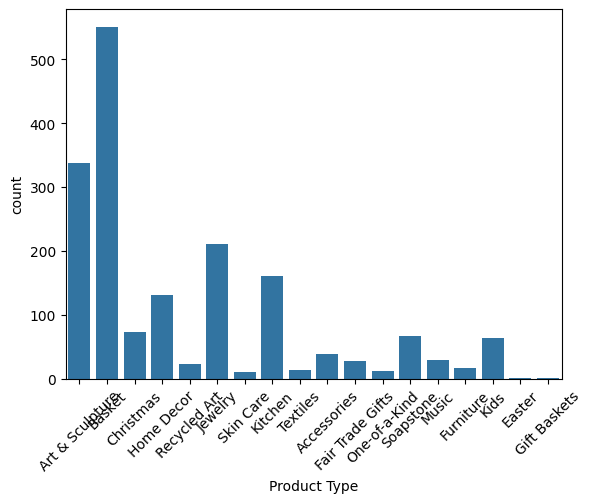

In [18]:
count=df.select_dtypes(include=['object'])
count.columns
sns.countplot(x='Product Type',data=df)
plt.xticks(rotation=45)
plt.show()

In [19]:
df['Product Type']=df['Product Type'].fillna(df['Product Type']).mode()[0]


In [20]:
df.isnull().sum()

Product Type       0
Net Quantity       0
Gross Sales        0
Discounts          0
Returns            0
Total Net Sales    0
dtype: int64

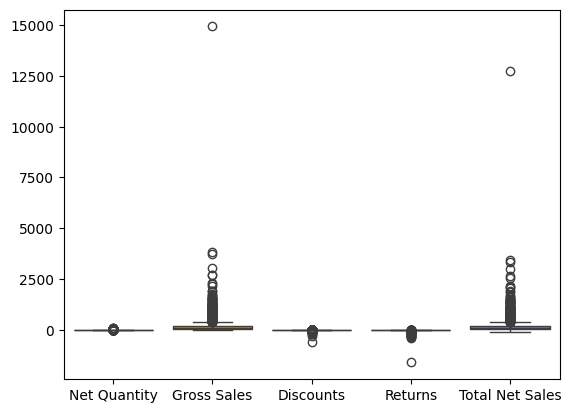

In [21]:
# outlier
num_cols=['Net Quantity', 'Gross Sales', 'Discounts', 'Returns',
       'Total Net Sales']
sns.boxplot(data=df[num_cols])
plt.show()

In [22]:
Q1=df['Net Quantity'].quantile(0.25)
Q2=df['Net Quantity'].quantile(0.50)
Q3=df['Net Quantity'].quantile(0.75)
print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['Net Quantity']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier        

1.0 2.0 4.0
3.0
8.5
-3.5


[34,
 13,
 12,
 17,
 47,
 17,
 20,
 90,
 10,
 11,
 30,
 19,
 15,
 37,
 33,
 20,
 32,
 17,
 9,
 11,
 58,
 58,
 96,
 15,
 9,
 30,
 32,
 18,
 14,
 10,
 69,
 10,
 15,
 18,
 11,
 12,
 13,
 15,
 59,
 9,
 11,
 9,
 25,
 11,
 24,
 10,
 11,
 9,
 11,
 18,
 19,
 16,
 16,
 9,
 16,
 15,
 18,
 25,
 24,
 9,
 18,
 13,
 42,
 31,
 20,
 15,
 40,
 19,
 13,
 18,
 12,
 14,
 9,
 9,
 11,
 12,
 9,
 10,
 22,
 10,
 9,
 22,
 13,
 21,
 25,
 17,
 18,
 16,
 25,
 17,
 45,
 10,
 14,
 17,
 10,
 12,
 12,
 29,
 9,
 16,
 21,
 11,
 13,
 18,
 16,
 11,
 16,
 16,
 9,
 11,
 9,
 16,
 14,
 10,
 9,
 18,
 13,
 11,
 29,
 21,
 16,
 16,
 13,
 15,
 10,
 15,
 15,
 15,
 12,
 22,
 9,
 13,
 13,
 13,
 9,
 19,
 12,
 12,
 20,
 9,
 12,
 9,
 12,
 13,
 10,
 10,
 16,
 15,
 16,
 14,
 10,
 13,
 9,
 10,
 15,
 13,
 11,
 11,
 10,
 12,
 9,
 10,
 9,
 9,
 10]

In [23]:
df=df[(df['Net Quantity']>=lower)& (df['Net Quantity']<=upper)]


In [24]:

outlier=[]
for x in df['Net Quantity']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier        

[]

In [25]:
# 'Gross Sales'
Q1=df['Gross Sales'].quantile(0.25)
Q2=df['Gross Sales'].quantile(0.50)
Q3=df['Gross Sales'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)


outlier=[]
for x in df['Gross Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier



44.0 88.0 170.0
126.0
359.0
-145.0


[1625.0,
 1467.0,
 1660.0,
 1225.0,
 1155.0,
 1125.0,
 1152.0,
 1050.0,
 1030.0,
 1225.0,
 990.0,
 1050.0,
 952.0,
 925.0,
 1150.0,
 1179.0,
 960.0,
 945.0,
 879.0,
 876.5,
 875.0,
 900.0,
 812.0,
 1035.0,
 770.0,
 775.0,
 770.0,
 740.0,
 700.0,
 696.0,
 725.0,
 700.0,
 645.0,
 631.0,
 638.0,
 625.0,
 636.0,
 625.0,
 891.0,
 600.0,
 580.0,
 576.0,
 574.0,
 565.0,
 564.0,
 575.0,
 550.0,
 588.0,
 590.0,
 544.0,
 550.0,
 550.0,
 550.0,
 525.0,
 525.0,
 522.0,
 564.0,
 525.0,
 506.0,
 500.0,
 500.0,
 460.0,
 460.0,
 460.0,
 476.0,
 450.0,
 450.0,
 450.0,
 460.0,
 458.0,
 536.0,
 440.0,
 440.0,
 440.0,
 615.0,
 450.0,
 408.0,
 440.0,
 410.0,
 432.0,
 385.0,
 385.0,
 414.0,
 379.0,
 374.0,
 384.0,
 380.0,
 370.0,
 428.0,
 396.0,
 360.0,
 360.0,
 370.0,
 364.0,
 360.0,
 440.0,
 440.0,
 365.0,
 408.0,
 390.0,
 564.0,
 380.0]

In [26]:
df=df[(df['Gross Sales']>=lower) &(df['Gross Sales']<=upper)]

In [27]:

outlier=[]
for x in df['Gross Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [28]:
#  'Discounts'
Q1=df[ 'Discounts'].quantile(0.25)
Q2=df[ 'Discounts'].quantile(0.50)
Q3=df[ 'Discounts'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)


outlier=[]
for x in df[ 'Discounts']:
 if((x>upper or (x<lower))):
    outlier.append(x)
outlier

-4.43 0.0 0.0
4.43
6.645
-11.075


[-11.6,
 -17.5,
 -17.5,
 -12.6,
 -35.0,
 -35.0,
 -22.0,
 -22.0,
 -16.2,
 -46.4,
 -11.41,
 -15.2,
 -38.4,
 -22.8,
 -70.0,
 -23.4,
 -12.0,
 -14.39,
 -14.4,
 -13.6,
 -28.8,
 -15.21,
 -15.31,
 -20.4,
 -15.2,
 -27.5,
 -12.5,
 -15.6,
 -11.6,
 -14.6,
 -19.69,
 -11.6,
 -24.0,
 -24.0,
 -24.0,
 -24.0,
 -19.5,
 -15.19,
 -14.0,
 -23.2,
 -19.6,
 -14.4,
 -22.0,
 -22.0,
 -13.01,
 -12.1,
 -13.4,
 -13.6,
 -20.5,
 -20.4,
 -16.79,
 -19.8,
 -14.39,
 -19.5,
 -19.5,
 -12.4,
 -11.6,
 -14.4,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -16.23,
 -11.3,
 -11.6,
 -14.0,
 -17.49,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.4,
 -17.4,
 -24.0,
 -16.8,
 -16.5,
 -16.5,
 -16.5,
 -16.5,
 -37.0,
 -37.0,
 -37.0,
 -15.2,
 -13.68,
 -14.5,
 -14.5,
 -14.5,
 -14.5,
 -14.5,
 -14.4,
 -14.4,
 -31.2,
 -13.6,
 -13.6,
 -13.49,
 -13.5,
 -13.0,
 -13.0,
 -20.4,
 -12.8,
 -11.14,
 -12.5,
 -12.5,
 -12.5,
 -12.5,
 -12.5,
 -18.75,
 -11.6,
 -11.6,
 -11.6,
 -11.6,
 -11.5,
 -11.5,
 

In [29]:
df=df[(df[ 'Discounts']>=lower)&(df[ 'Discounts']<=upper)]

In [30]:

outlier=[]
for x in df[ 'Discounts']:
 if((x>upper or (x<lower))):
    outlier.append(x)
outlier

[]

In [31]:
Q1=df['Returns'].quantile(0.25)
Q2=df['Returns'].quantile(0.50)
Q3=df['Returns'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['Returns']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

0.0 0.0 0.0
0.0
0.0
0.0


[-34.0,
 -38.88,
 -38.0,
 -38.0,
 -104.0,
 -38.0,
 -34.0,
 -38.0,
 -43.5,
 -128.0,
 -58.5,
 -34.2,
 -57.6,
 -140.0,
 -110.0,
 -56.0,
 -110.0,
 -37.12,
 -44.0,
 -10.8,
 -42.0,
 -34.2,
 -58.0,
 -34.0,
 -32.0,
 -54.0,
 -232.0,
 -28.0,
 -26.25,
 -44.0,
 -48.0,
 -28.0,
 -46.0,
 -68.4,
 -34.0,
 -38.0,
 -34.0,
 -28.0,
 -56.0,
 -14.4,
 -26.0,
 -34.0,
 -48.0,
 -1.0,
 -195.0,
 -28.0,
 -28.79,
 -25.19,
 -28.0,
 -16.5,
 -106.25]

In [32]:
df=df[(df['Returns']>=lower) &(df['Returns']<=upper)]

In [33]:
outlier=[]
for x in df['Returns']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [34]:
# , , ].quantile(0.)      'Total Net Sales'
Q1=df['Total Net Sales'].quantile(0.25)
Q2=df['Total Net Sales'].quantile(0.50)
Q3=df['Total Net Sales'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
lower

outlier=[]
for x in df['Total Net Sales']:
    if((x>upper or(x<lower))):
        outlier.append(x)
outlier
                   

38.0 68.4 129.2
91.19999999999999
266.0


[350.0,
 350.0,
 350.0,
 350.0,
 348.0,
 348.0,
 348.0,
 344.0,
 336.0,
 332.85,
 330.0,
 330.0,
 330.0,
 319.0,
 319.0,
 315.0,
 310.0,
 307.0,
 307.0,
 305.5,
 300.0,
 298.0,
 296.0,
 295.6,
 293.0,
 290.0,
 288.0,
 288.0,
 288.0,
 285.0,
 278.4,
 278.39,
 273.68,
 272.0,
 272.0,
 271.2,
 270.0,
 268.48]

In [35]:
df=df[(df['Total Net Sales']>=lower)&(df['Total Net Sales']<=upper)]

In [36]:

outlier=[]
for x in df['Total Net Sales']:
    if((x>upper or(x<lower))):
        outlier.append(x)
outlier
           

[]

In [37]:
df.reset_index(drop=True,inplace=True)

In [38]:
df

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Basket,4,272.0,-6.79,0.0,265.21
1,Basket,4,272.0,-6.80,0.0,265.20
2,Basket,3,264.0,0.00,0.0,264.00
3,Basket,2,264.0,0.00,0.0,264.00
4,Basket,4,256.0,0.00,0.0,256.00
...,...,...,...,...,...,...
1255,Basket,1,12.0,0.00,0.0,12.00
1256,Basket,1,12.0,0.00,0.0,12.00
1257,Basket,1,12.0,0.00,0.0,12.00
1258,Basket,1,12.0,0.00,0.0,12.00


In [39]:
# encoding

df['Product Type'].nunique()

1

In [56]:
from sklearn.preprocessing import OneHotEncoder

In [40]:

# df1=pd.get_dummies(df)
# df1

In [41]:
# df_1=pd.get_dummies(df1)
# df_1.astype('int')

In [42]:
# label encodng
df.head()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Basket,4,272.0,-6.79,0.0,265.21
1,Basket,4,272.0,-6.80,0.0,265.20
2,Basket,3,264.0,0.00,0.0,264.00
3,Basket,2,264.0,0.00,0.0,264.00
4,Basket,4,256.0,0.00,0.0,256.00


In [43]:
from sklearn.preprocessing import LabelEncoder


In [44]:
le=LabelEncoder()

In [45]:
df['Product Type']=le.fit_transform(df['Product Type'])
df['Product Type']

0       0
1       0
2       0
3       0
4       0
       ..
1255    0
1256    0
1257    0
1258    0
1259    0
Name: Product Type, Length: 1260, dtype: int64

In [46]:
x=df.drop(['Discounts','Product Type'],axis=1)
x

,Net Quantity,Gross Sales,Returns,Total Net Sales
0,4,272.0,0.0,265.21
1,4,272.0,0.0,265.20
2,3,264.0,0.0,264.00
3,2,264.0,0.0,264.00
4,4,256.0,0.0,256.00
...,...,...,...,...
1255,1,12.0,0.0,12.00
1256,1,12.0,0.0,12.00
1257,1,12.0,0.0,12.00
1258,1,12.0,0.0,12.00


In [47]:
y=df[['Discounts','Product Type']]
y

,Discounts,Product Type
0,-6.79,0
1,-6.80,0
2,0.00,0
3,0.00,0
4,0.00,0
...,...,...
1255,0.00,0
1256,0.00,0
1257,0.00,0
1258,0.00,0


In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
minmax=MinMaxScaler(feature_range=(0,1))

In [50]:
x1=minmax.fit_transform(x)
x1

array([[0.42857143, 1.        , 0.        , 1.        ],
       [0.42857143, 1.        , 0.        , 0.99996074],
       [0.28571429, 0.96940727, 0.        , 0.9952495 ],
       ...,
       [0.        , 0.00573614, 0.        , 0.00588905],
       [0.        , 0.00573614, 0.        , 0.00588905],
       [0.        , 0.        , 0.        , 0.        ]], shape=(1260, 4))

In [51]:
x

,Net Quantity,Gross Sales,Returns,Total Net Sales
0,4,272.0,0.0,265.21
1,4,272.0,0.0,265.20
2,3,264.0,0.0,264.00
3,2,264.0,0.0,264.00
4,4,256.0,0.0,256.00
...,...,...,...,...
1255,1,12.0,0.0,12.00
1256,1,12.0,0.0,12.00
1257,1,12.0,0.0,12.00
1258,1,12.0,0.0,12.00


In [53]:
x2=pd.DataFrame(x1,columns=['Net Quantity','Gross Sales','Returns','Total Net Scales'])
x2

,Net Quantity,Gross Sales,Returns,Total Net Scales
0,0.428571,1.000000,0.0,1.000000
1,0.428571,1.000000,0.0,0.999961
2,0.285714,0.969407,0.0,0.995249
3,0.142857,0.969407,0.0,0.995249
4,0.428571,0.938815,0.0,0.963841
...,...,...,...,...
1255,0.000000,0.005736,0.0,0.005889
1256,0.000000,0.005736,0.0,0.005889
1257,0.000000,0.005736,0.0,0.005889
1258,0.000000,0.005736,0.0,0.005889


In [54]:
x3=pd.concat([x2,y],axis=1)
x3

,Net Quantity,Gross Sales,Returns,Total Net Scales,Discounts,Product Type
0,0.428571,1.000000,0.0,1.000000,-6.79,0
1,0.428571,1.000000,0.0,0.999961,-6.80,0
2,0.285714,0.969407,0.0,0.995249,0.00,0
3,0.142857,0.969407,0.0,0.995249,0.00,0
4,0.428571,0.938815,0.0,0.963841,0.00,0
...,...,...,...,...,...,...
1255,0.000000,0.005736,0.0,0.005889,0.00,0
1256,0.000000,0.005736,0.0,0.005889,0.00,0
1257,0.000000,0.005736,0.0,0.005889,0.00,0
1258,0.000000,0.005736,0.0,0.005889,0.00,0


In [55]:
df.describe()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
count,1260.0,1260.000000,1260.000000,1260.000000,1260.0,1260.000000
mean,0.0,2.052381,86.357619,-1.513262,0.0,84.844357
std,0.0,1.510499,58.416861,2.595090,0.0,57.965189
min,0.0,1.000000,10.500000,-11.000000,0.0,10.500000
25%,0.0,1.000000,38.000000,-2.800000,0.0,37.807500
50%,0.0,1.000000,68.000000,0.000000,0.0,68.000000
75%,0.0,3.000000,125.250000,0.000000,0.0,125.000000
max,0.0,8.000000,272.000000,0.000000,0.0,265.210000


In [59]:
num_cols=['Net Quantity','Gross Sales','Discounts','Returns','Total Net Sales']

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler=StandardScaler()

In [60]:
df[num_cols]=scaler.fit_transform(df[num_cols])


In [61]:
df

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,0,1.289900,3.179152,-2.034162,0.0,3.112856
1,0,1.289900,3.179152,-2.038017,0.0,3.112683
2,0,0.627604,3.042151,0.583357,0.0,3.091973
3,0,-0.034692,3.042151,0.583357,0.0,3.091973
4,0,1.289900,2.905150,0.583357,0.0,2.953904
...,...,...,...,...,...,...
1255,0,-0.696988,-1.273385,0.583357,0.0,-1.257190
1256,0,-0.696988,-1.273385,0.583357,0.0,-1.257190
1257,0,-0.696988,-1.273385,0.583357,0.0,-1.257190
1258,0,-0.696988,-1.273385,0.583357,0.0,-1.257190
